# 09 · Interactive map projection: rotate the sphere inside the map

`mt.geodesicdome.interactive.ProjectionViewer` draws a dome in a map projection and lets you rotate the
sphere underneath it. Unlike `projection.build` (notebook 05) it cuts the triangles that cross the
±180° seam and the poles exactly, so no triangle is lost however the sphere is turned.

**Live figures need `ipympl`** (`pip install ipympl`): then drag on the map to rotate the sphere, and
use the keys **arrows** (5°, shift = 1°), **, / .** (roll), **r** (reset), **p** (next projection),
**g** (graticule) and **e** (edges) after clicking on the figure. Without `ipympl` the figure is a
static image, but the sliders below still rotate it.

Script version: [`examples/09_interactive_projection.py`](../09_interactive_projection.py) · Needs: numpy, matplotlib, ipywidgets (optional: `ipympl` for live, rotatable figures)

<sub>SPDX-License-Identifier: AGPL-3.0-or-later · Copyright (C) 2022-2026 Masahiro Takatsuka. See the NOTICE file for attribution terms.</sub>

## Set-up

In [1]:
import nb_setup  # makes mt.geodesicdome and examples/dome_utils.py importable from a checkout

WIDGET = nb_setup.setup()  # live figures with ipympl, static images otherwise

figures: live (ipympl) -- drag 3D plots to rotate them


In [2]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from nb_setup import LiveFigure

from mt.geodesicdome.grid.geodesicdome import GeodesicDome
from mt.geodesicdome.interactive import ProjectionViewer
from mt.geodesicdome.interactive.viewer import DEFAULT_PROJECTIONS

print('projections:', list(DEFAULT_PROJECTIONS))

projections: ['Equal Earth', 'Kavrayskiy VII', 'Wagner VI', 'Wagner III']


## Colourings

`colors=` accepts `'position'` (a fixed colour from each face's original position, so you can see where
every part of the sphere has gone), `'icosahedron'`, `'data'` (from `vertex.data`), a single colour, or an
array with one value or RGB(A) row per stored vertex, unique point or face. Scalars go through `cmap`.

In [3]:
FREQ = 8
dome = GeodesicDome(FREQ)

# a smooth scalar field on the sphere: a few Gaussian bumps around random centres
xyz = dome.get_all_xyz()
centres = np.random.default_rng(3).normal(size=(6, 3))
centres /= np.linalg.norm(centres, axis=1, keepdims=True)
bumps = np.exp(-(1 - xyz @ centres.T) * 6).sum(axis=1)          # one value per stored vertex

# anything stored with vertex.set_data can be shown -- here an RGB colour per vertex
for v in dome.get_all_vertices():
    v.set_data(0.5 + 0.5 * np.array([np.sin(3 * v.coord[0]), v.coord[1], np.cos(2 * v.coord[2])]))

COLOURINGS = {'position': ('position', 'viridis'), 'icosahedron': ('icosahedron', 'viridis'),
              'bumps (scalar field)': (bumps, 'magma'), 'data (vertex.set_data)': ('data', 'viridis')}

## The viewer

Label(value='Equal Earth · centre of view: lat +0.0°, lon +0.0°')

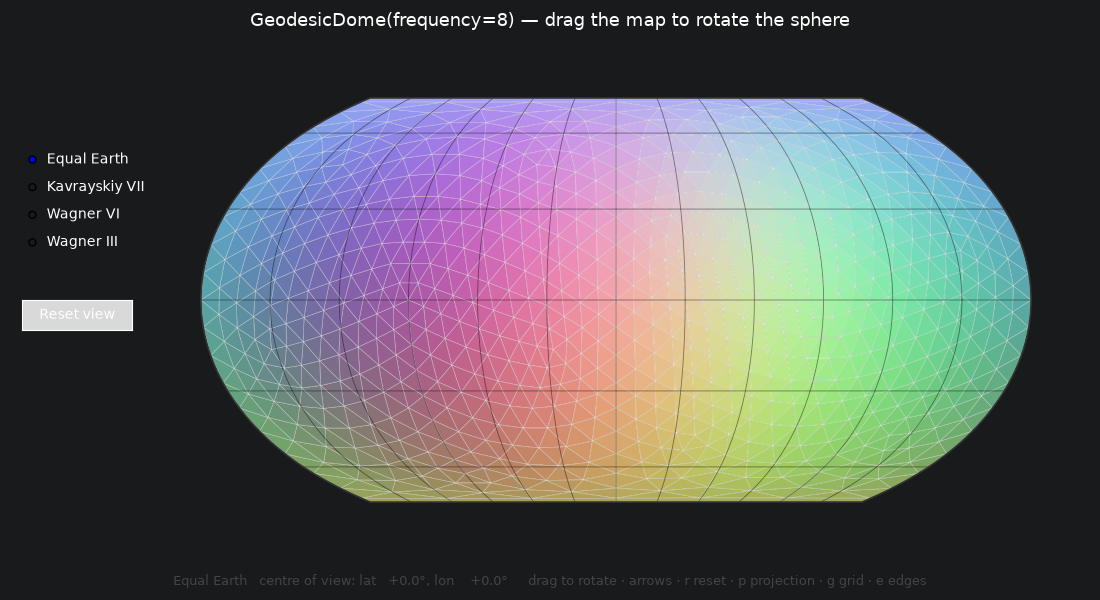

In [4]:
with plt.ioff():                                    # displayed below, once
    viewer = ProjectionViewer(dome, 'Equal Earth', colors='position', figsize=(11, 6),
                              title=f'GeodesicDome(frequency={FREQ}) — drag the map to rotate the sphere')
live = LiveFigure(fig=viewer.fig)

status = widgets.Label()
viewer.on_rotate(lambda vw: setattr(status, 'value', '{} · centre of view: lat {:+.1f}°, lon {:+.1f}°'.format(
    vw.projection_name, *vw.centre)))
viewer.update()
display(status)
live.show() if WIDGET else display(viewer.fig)

### Controls

These drive the viewer above when figures are live (and draw a fresh image when they are static).
`set_view(lat, lon, roll)` puts a point of the original sphere at the centre of the map;
`rotate(d_lon, d_lat, roll)` turns it relative to the current view, like a drag.

In [5]:
projection = widgets.Dropdown(options=list(DEFAULT_PROJECTIONS), value='Equal Earth', description='projection')
colouring = widgets.Dropdown(options=list(COLOURINGS), value='position', description='colour by')
lat = widgets.FloatSlider(value=0, min=-90, max=90, step=1, description='centre lat')
lon = widgets.FloatSlider(value=0, min=-180, max=180, step=1, description='centre lon')
roll = widgets.FloatSlider(value=0, min=-180, max=180, step=1, description='roll')
edges = widgets.Checkbox(value=True, description='edges')
graticule = widgets.Checkbox(value=True, description='graticule')


def apply(projection, colouring, lat, lon, roll, edges, graticule):
    colors, cmap = COLOURINGS[colouring]
    viewer.cmap = plt.get_cmap(cmap)
    viewer.set_colors(colors)
    viewer.show_edges, viewer.show_graticule = edges, graticule
    if projection != viewer.projection_name:
        viewer.set_projection(projection)
    viewer.set_view(lat, lon, roll)                 # redraws
    if not WIDGET:
        display(viewer.fig)


out = widgets.interactive_output(apply, dict(projection=projection, colouring=colouring, lat=lat, lon=lon,
                                             roll=roll, edges=edges, graticule=graticule))
display(widgets.VBox([widgets.HBox([projection, colouring, edges, graticule]),
                      widgets.HBox([lat, lon, roll])]), out)

Output()

## Driving the viewer from code

The same calls work in a script. For example, centre the map on Sydney, then turn the sphere three times
by 30° as a horizontal drag would, reporting the centre of the view through an `on_rotate` callback.
(A horizontal drag spins the sphere about the map's vertical axis, so the centre moves along a great
circle rather than along a parallel.)

In [6]:
log = []
viewer.on_rotate(lambda vw: log.append(vw.centre))

viewer.set_view(-33.9, 151.2)
for _ in range(3):
    viewer.rotate(d_lon=30)
for lat_, lon_ in log[-4:]:
    print(f'centre of view: lat {lat_:+6.1f}°, lon {lon_:+7.1f}°')
if not WIDGET:
    display(viewer.fig)

centre of view: lat  -33.9°, lon  +151.2°
centre of view: lat  -28.9°, lon  +116.4°
centre of view: lat  -16.2°, lon   +86.8°
centre of view: lat   +0.0°, lon   +61.2°


## Record an animation (optional)

Set `MAKE_ANIMATION = True` to spin the sphere once while tilting the pole towards you and back, and play
it here. It is off by default because the animation is embedded in the notebook and makes it large.

In [7]:
MAKE_ANIMATION = False

if MAKE_ANIMATION:
    import matplotlib.animation as animation
    from IPython.display import HTML

    viewer.reset()
    frames = 36

    def step(i):
        viewer.rotate(d_lon=360 / frames, d_lat=35 * np.cos(2 * np.pi * i / frames) * 2 * np.pi / frames)
        return []

    anim = animation.FuncAnimation(viewer.fig, step, frames=frames, interval=80, blit=False)
    display(HTML(anim.to_jshtml(default_mode='loop')))